In [ ]:
# Applying PCA Manually (Without SkLearn)

import numpy as np
import pandas as pd

import plotly.express as px
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

In [2]:
# Generation of Normal Distributed Data 

# Set seed for reproducibility so the "random" numbers are the same every time you run it
np.random.seed(7) 

# --- Class 1 Generation ---
# Define the mean (center) and covariance (spread/shape) for the first cluster
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]]) # Identity matrix: features are independent
# Generate 20 samples from a 3D Gaussian distribution centered at (0,0,0)
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

# Create DataFrame for Class 1 and assign the ground truth label '1'
df = pd.DataFrame(class1_sample, columns=['feature1','feature2','feature3'])
df['target'] = 1

# --- Class 2 Generation ---
# Define a different mean to shift the second cluster to center at (1,1,1)
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
# Generate 20 samples for the second class
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

# Create DataFrame for Class 2 and assign the ground truth label '0'
df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])
df1['target'] = 0

# --- Data Consolidation ---
# Combine both classes into a single DataFrame (40 rows total)
# Note: .append() is deprecated in newer Pandas; use pd.concat([df, df1]) instead
df = pd.concat([df, df1])

# Shuffle the rows so the model doesn't learn based on the order of the classes
df = df.sample(40)


In [3]:
# plot Data In 3-D Space to visualize

fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'], color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')), selector=dict(mode='markers'))

fig.show()

Apply PCA Steps

In [4]:
# Step 1 - Apply standard scaling

scaler = StandardScaler()
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

# Step 2 - Find Covariance Matrix

covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print('Eigen Values : \n',eigen_values)

print('Eigen Vectors : \n', eigen_vectors)

Covariance Matrix:
 [[1.02564103 0.15722572 0.11161011]
 [0.15722572 1.02564103 0.25504629]
 [0.11161011 0.25504629 1.02564103]]
Eigen Values : 
 [1.38244902 0.92934305 0.76513101]
Eigen Vectors : 
 [[ 0.47180421  0.86580205  0.16669614]
 [ 0.64079753 -0.20684793 -0.73931892]
 [ 0.60562308 -0.45563225  0.65239554]]


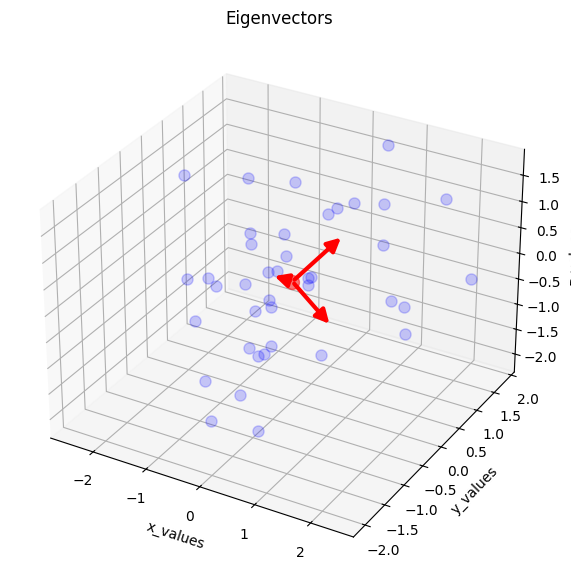

In [5]:
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

# Custom class to render arrows in a 3D coordinate system
# It inherits from FancyArrowPatch (normally 2D) and overrides the draw method
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        # Use self.axes.M instead of renderer.M
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        # Use self.axes.M here as well
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)



# Initialize a 7x7 figure with 3D projection
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Plot the individual data points as blue circles with low transparency (alpha)
ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)

# Plot the center of the data (mean) as a larger red circle
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)

# Iterate through each eigenvector to draw them as 3D arrows starting from the mean
for v in eigen_vectors.T:
    # 'mutation_scale' controls arrowhead size; 'lw' is line width
    a = Arrow3D([df['feature1'].mean(), v[0]], 
                [df['feature2'].mean(), v[1]], 
                [df['feature3'].mean(), v[2]], 
                mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a) # Add the custom arrow artist to the 3D plot

# Set axis labels and title for clarity
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')

plt.show()

In [6]:
# Select one Eigen Vector

pc = eigen_vectors[0:1]

# Transform Data Points -> Project Data Points on PC1

transformed_df = np.dot(df.iloc[:,0:3],pc.T)
new_df = pd.DataFrame(transformed_df,columns=['PC1'])
new_df['target'] = df['target'].values

In [7]:

# Ensure target is string for discrete coloring
new_df['target'] = new_df['target'].astype('str')

# Create the 1D scatter plot
fig = px.scatter(new_df, 
                 x='PC1', 
                 y=np.zeros(len(new_df)), # Maps all points to 0 on the y-axis
                 color='target',
                 color_discrete_sequence=px.colors.qualitative.G10,
                 title="Visualization of PC1 Only")

# Apply your custom marker styling
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2, color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

# FIX: Use update_yaxes (plural) to hide the meaningless Y-axis
fig.update_yaxes(visible=False, showticklabels=False, showgrid=False, zeroline=False)

fig.show()


In [8]:
# Select 2 - Eigen Vector

pc = eigen_vectors[0:2]

# Transform Data Points -> Project Points On 2D Plane (Axes -> PC1, PC2)

transformed_df = np.dot(df.iloc[:,0:3],pc.T)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values

In [9]:
import plotly.express as px

# Ensure target is categorical for the legend
new_df['target'] = new_df['target'].astype('str')

# Create a 2D scatter plot for the first two principal components
fig = px.scatter(new_df, 
                 x='PC1', 
                 y='PC2', 
                 color='target',
                 color_discrete_sequence=px.colors.qualitative.G10,
                 title="PCA: PC1 vs PC2",
                 labels={'PC1': 'First Principal Component', 'PC2': 'Second Principal Component'})

# Apply the requested marker styling
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

# Optimize layout for better readability
fig.update_layout(template="plotly_white",
                  legend_title_text='Class Label')

fig.show()
